# Earth-Moon System

This notebook simulates the Earth-Moon system and visualises the Moon's orbit in an Earth-centred reference frame.

In [1]:
import orbit
import numpy as np
import matplotlib.pyplot as plt

print('orbit version:', orbit.__version__)

orbit version: 2.0.0-dev


## Run the simulation

Simulate 30 days with a 60-second timestep — fine enough to resolve the lunar orbit accurately.

In [2]:
SECONDS_PER_MINUTE = 60.0
STEPS_PER_DAY      = 24 * 60          # one step per minute
DAYS               = 30

result = orbit.simulate(
    '../systems/earth_moon_horizons.json',
    steps=STEPS_PER_DAY * DAYS,
    dt=SECONDS_PER_MINUTE,
)

print('Bodies:', result.body_names)    # ['Sun', 'Earth', 'Moon']
print('Steps: ', len(result.snapshots))

Bodies: ['Sun', 'Earth', 'Moon']
Steps:  43200


## Extract positions

`positions_numpy()` returns shape `(n_steps, n_bodies, 3)`.  
Body order matches `result.body_names`: index 0 = Sun, 1 = Earth, 2 = Moon.

In [3]:
pos = result.positions_numpy()         # (n_steps, 3, 3)  metres

earth = pos[:, 1, :]                   # (n_steps, 3)
moon  = pos[:, 2, :]                   # (n_steps, 3)

# Moon relative to Earth (Earth-centred frame)
moon_rel = moon - earth                # (n_steps, 3)

KM = 1e3
moon_rel_km = moon_rel / KM

print('Moon distance at step 0: {:.0f} km'.format(np.linalg.norm(moon_rel_km[0])))

Moon distance at step 0: 381736 km


## Plot the lunar orbit

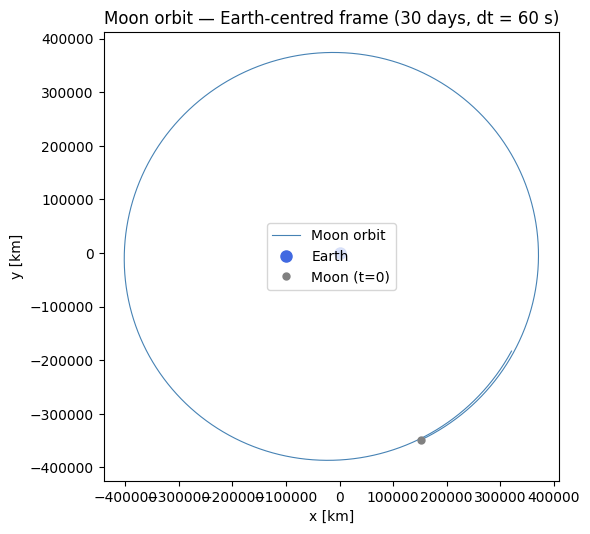

In [4]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(moon_rel_km[:, 0], moon_rel_km[:, 1], lw=0.8, color='steelblue', label='Moon orbit')
ax.plot(0, 0, 'o', ms=8, color='royalblue', label='Earth')
ax.plot(moon_rel_km[0, 0], moon_rel_km[0, 1], 'o', ms=5, color='grey', label='Moon (t=0)')

ax.set_xlabel('x [km]')
ax.set_ylabel('y [km]')
ax.set_title('Moon orbit — Earth-centred frame (30 days, dt = 60 s)')
ax.set_aspect('equal')
ax.legend()
plt.tight_layout()
plt.show()

## Orbital period estimate

The Moon's distance from Earth oscillates with its orbital period (~27.3 days).  
We can estimate the period by finding the time of the first periapsis return.

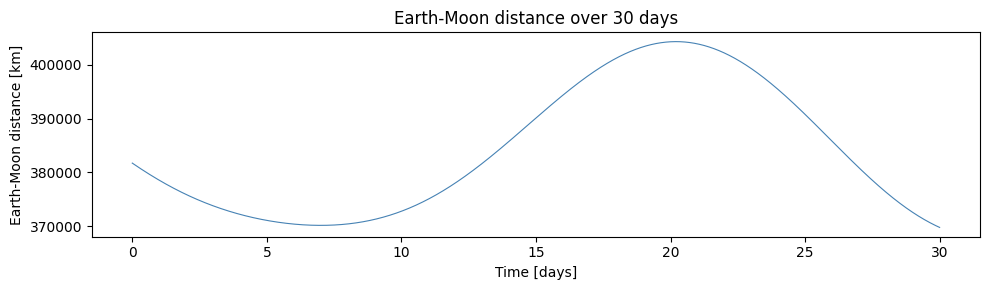

Min distance (perigee):  369,787 km
Max distance (apogee):   404,299 km


In [5]:
dist_km = np.linalg.norm(moon_rel_km, axis=1)   # (n_steps,)
t_days  = np.arange(len(dist_km)) / STEPS_PER_DAY

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(t_days, dist_km, lw=0.8, color='steelblue')
ax.set_xlabel('Time [days]')
ax.set_ylabel('Earth-Moon distance [km]')
ax.set_title('Earth-Moon distance over 30 days')
plt.tight_layout()
plt.show()

print(f'Min distance (perigee):  {dist_km.min():,.0f} km')
print(f'Max distance (apogee):   {dist_km.max():,.0f} km')